# ✅ 数学过程：

> 使用**梯度下降法**来拟合一个最简单的一元线性函数 $y = wx$，目标是最小化预测值与真实值之间的**均方误差损失（MSE）**。

---

## 📐 1. 数学建模部分

### ✅ 训练数据：

给出输入输出对 $(x_i, y_i)$，如下：

$$
\begin{aligned}
x &= \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}, \quad 
y = \begin{bmatrix} 2 \\ 4 \\ 6 \end{bmatrix}
\end{aligned}
$$

### ✅ 模型函数（线性回归）：

定义一个只有一个参数的线性模型：

$$
\hat{y}_i = f(x_i) = w \cdot x_i
$$

初始时：$w = 0$

---

## 🎯 2. 目标函数（损失函数）

我们希望模型预测值 $\hat{y}_i$ 越接近真实值 $y_i$ 越好。

所以定义均方误差（Mean Squared Error, MSE）作为损失函数：

$$
L(w) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{3} \sum_{i=1}^{3} (y_i - w x_i)^2
$$

---

## 🔁 3. 优化过程（梯度下降）

用**梯度下降**法更新参数 $w$，使得 $L(w)$ 最小。

---

### 🧮 第一步：计算梯度 $\frac{dL}{dw}$

我们对损失函数 $L(w)$ 对 $w$ 求导：

$$
\frac{dL}{dw} = \frac{1}{n} \sum_{i=1}^{n} 2(w x_i - y_i) \cdot x_i
$$

对于本例中的数据：

$$
\frac{dL}{dw} = \frac{2}{3} \left[ (wx_1 - y_1)x_1 + (wx_2 - y_2)x_2 + (wx_3 - y_3)x_3 \right]
$$

PyTorch 通过 `loss.backward()` 自动计算这部分导数。

---

### 🔄 第二步：更新参数 $w$

$$
w := w - \eta \cdot \frac{dL}{dw}
$$

其中 $\eta = 0.1$ 是学习率（learning rate），控制“每次往下降多大步”。

---

### 🔁 第三步：重复 100 次

每次：

* 预测值 $\hat{y} \leftarrow x @ w$
* 损失 $L(w) = MSE$
* 梯度 $\frac{dL}{dw}$
* 参数更新 $w := w - \eta \cdot \frac{dL}{dw}$

---

## 🧪 最终结果

由于：

$$
y = 2x
$$

是训练数据的真实规律，经过足够多次迭代，训练出的 $w$ 应该会接近 2。

---

## 📊 可视化（选讲）

你可以画出：

* 损失函数 $L(w)$ 的曲线（关于 w 的抛物线）
* 每次迭代后 $w$ 向最优解靠近的路径

## ✅ Bonus：这段代码在 PyTorch 中的对应关系

| 数学符号            | PyTorch 变量                          |
| --------------- | ----------------------------------- |
| $x$             | `x` 张量（输入）                          |
| $y$             | `y` 张量（目标）                          |
| $w$             | `w`（模型参数）                           |
| $\hat{y} = xw$  | `y_pred = x @ w`                    |
| $L(w)$          | `loss = ((y - y_pred) ** 2).mean()` |
| $\nabla_w L(w)$ | `loss.backward()` 自动计算              |
| 参数更新            | `w -= 0.1 * w.grad`                 |



# 线性回归

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

## 1. 训练数据（向量形式）

In [17]:
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])  # 对应 y = 2x + 1

# 2. 定义模型（包含权重 w 和偏置 b）

In [18]:
model = nn.Linear(in_features=1, out_features=1)  # y = wx + b

# 3. 定义损失函数和优化器

In [19]:
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 4. 训练循环

In [ ]:
for epoch in range(1000):
    y_pred = model(x)                 # 前向传播
    loss = loss_fn(y_pred, y)        # 计算损失
    optimizer.zero_grad()            # 清除梯度
    loss.backward()                  # 反向传播
    optimizer.step()                 # 更新参数

# 5. 查看训练结果

In [25]:
w = model.weight.item()
b = model.bias.item()
print(f"训练出的模型: y = {w:.2f}x + {b:.2f}")

训练出的模型: y = 2.00x + 1.00


# 非线性回归

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

## 1. 生成训练数据：y = sin(x)

In [3]:
x_np = np.linspace(-2 * np.pi, 2 * np.pi, 200).reshape(-1, 1)
y_np = np.sin(x_np)

x = torch.tensor(x_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

## 2. 定义非线性模型（MLP 多层感知机）

In [4]:
model = nn.Sequential(
    nn.Linear(1, 32),   # 输入层 -> 隐藏层
    nn.Tanh(),          # 非线性激活函数
    nn.Linear(32, 1)    # 输出层
)

## 3. 损失函数和优化器

In [5]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## 4. 训练循环

In [6]:
for epoch in range(1000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.886749
Epoch 100, Loss: 0.079730
Epoch 200, Loss: 0.058837
Epoch 300, Loss: 0.046085
Epoch 400, Loss: 0.036076
Epoch 500, Loss: 0.026933
Epoch 600, Loss: 0.017156
Epoch 700, Loss: 0.007791
Epoch 800, Loss: 0.002875
Epoch 900, Loss: 0.001093


## 5. 可视化拟合结果

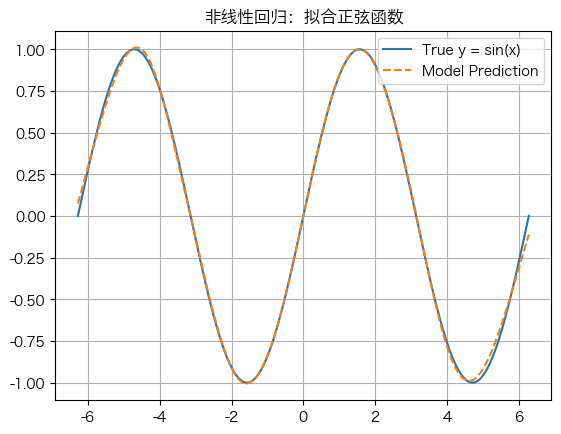

In [16]:
with torch.no_grad():
    y_fit = model(x)
# 字体路径（确保路径正确）
font_path = "/System/Library/Fonts/Hiragino Sans GB.ttc"
font_prop = font_manager.FontProperties(fname=font_path)

# 设置全局字体
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False        # 正确显示负号
plt.plot(x_np, y_np, label="True y = sin(x)")
plt.plot(x_np, y_fit.numpy(), label="Model Prediction", linestyle='--')
plt.legend()
plt.title("非线性回归：拟合正弦函数")
plt.grid(True)
plt.show()

# Softmax 多分类（识别 MNIST 手写数字）

In [46]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## 1. 加载数据

In [47]:
train_data = datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

## 2. 定义模型（一个最简单的线性层）

In [48]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28*28, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # 展平图像
        return self.linear(x)  # 输出10个值（未经过 softmax）

model = Model()

## 3. 损失函数与优化器

In [49]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

## 4. 训练循环（1轮即可）

In [50]:
for images, labels in train_loader:
    preds = model(images)             # 前向传播
    loss = loss_fn(preds, labels)     # 计算损失

    optimizer.zero_grad()             # 梯度清零
    loss.backward()                   # 反向传播
    optimizer.step()                  # 参数更新
    break 

## 5. 结果

In [51]:
print(f"Loss after one batch: {loss.item():.4f}")

Loss after one batch: 2.2959
